# Actividad Evaluable: Patrones con K-means

Para determinar patrones con K-means comenzamos importando las librerias necesarias y cargando los datos...

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns

df = pd.read_csv("Facebook_Marketplace_data.csv")

Y mostramos la información del dataframe leído y mostramos así como algunas filas para saber que datos estamos tratando y si hay columnas que no nos sirvan:

In [24]:
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   int64  
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(10), object(2)
memory

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


Dado a que *status_id* y las columnas *Column1* a *Column4* no nos dicen nada haremos una copia del dataframe y a esas columnas les haremos un drop (las eliminaremos)

In [25]:
df_clean = df.copy()
df_clean = df_clean.drop(["status_id", "Column1", "Column2", "Column3", "Column4"], axis=1)
print(df_clean.info())
display(df_clean.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   status_type       7050 non-null   object
 1   status_published  7050 non-null   object
 2   num_reactions     7050 non-null   int64 
 3   num_comments      7050 non-null   int64 
 4   num_shares        7050 non-null   int64 
 5   num_likes         7050 non-null   int64 
 6   num_loves         7050 non-null   int64 
 7   num_wows          7050 non-null   int64 
 8   num_hahas         7050 non-null   int64 
 9   num_sads          7050 non-null   int64 
 10  num_angrys        7050 non-null   int64 
dtypes: int64(9), object(2)
memory usage: 606.0+ KB
None


,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0


Ya que *status_published* son fechas lo convierto a un tipo de dato **datetime** en formato mm/dd/yyyy hh/mm (GeeksforGeeks, 2025a)

In [26]:
df_clean["status_published"] = pd.to_datetime(df_clean["status_published"], format="%m/%d/%Y %H:%M")
print(df_clean.info())
display(df_clean.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   status_type       7050 non-null   object        
 1   status_published  7050 non-null   datetime64[ns]
 2   num_reactions     7050 non-null   int64         
 3   num_comments      7050 non-null   int64         
 4   num_shares        7050 non-null   int64         
 5   num_likes         7050 non-null   int64         
 6   num_loves         7050 non-null   int64         
 7   num_wows          7050 non-null   int64         
 8   num_hahas         7050 non-null   int64         
 9   num_sads          7050 non-null   int64         
 10  num_angrys        7050 non-null   int64         
dtypes: datetime64[ns](1), int64(9), object(1)
memory usage: 606.0+ KB
None


,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,video,2018-04-22 06:00:00,529,512,262,432,92,3,1,1,0
1,photo,2018-04-21 22:45:00,150,0,0,150,0,0,0,0,0
2,video,2018-04-21 06:17:00,227,236,57,204,21,1,1,0,0
3,photo,2018-04-21 02:29:00,111,0,0,111,0,0,0,0,0
4,photo,2018-04-18 03:22:00,213,0,0,204,9,0,0,0,0


Si bien hacer un cambio de tipo de dato en el dataframe en cuanto a cuándo fueron publicadas las publicaciones no es necesario lo hace más entendible y ya hace que el dato de usarse se use como lo que es, una fecha y no un objeto cualquiera en el dataset

### Realizando agrupaciones con respecto a los tipos de interacciones principales (comentarios, compartidos y likes)

Primero seleccionare las columnas de comentarios, compartidos y likes y les haré un escalado (W3Schools.com, s. f.-b) (Introduction To k-Means Clustering With Scikit-learn In Python, 2023):

In [27]:
X = df_clean[['num_comments', 'num_shares', 'num_likes']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Luego determinaremos el número de clusters óptimos con el método del codo:

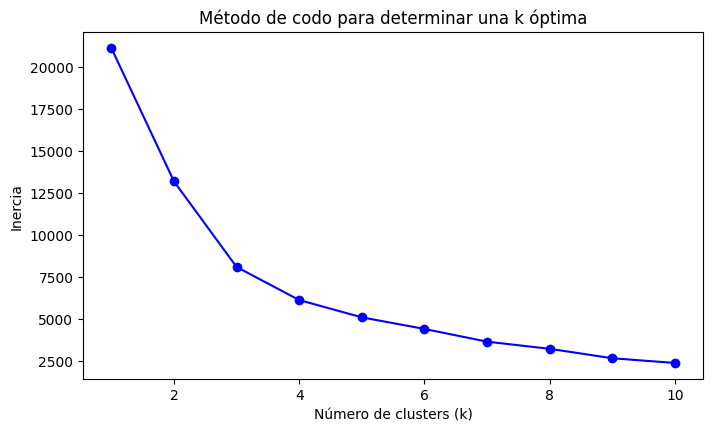

In [ ]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4.5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método de codo para determinar una k óptima')
plt.show()

Ahora aplicaremos K-means con un K de 3 ya que a partir de cuatro ya se comienza a normalizar

In [39]:
kmeans = KMeans(n_clusters = 3, random_state = 42)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

Verificamos los centros de los clusters

In [40]:
centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns = ['num_comments', 'num_shares', 'num_likes'])
print("Centros de los clusters:")
print(centers)

Centros de los clusters:
   num_comments  num_shares    num_likes
0     85.185604   19.009272   105.403583
1   3266.393548  502.316129   527.416129
2     71.862069   14.549072  1808.679045


Y visualizamos los clusters, primero entre comentarios y likes y después entre comentarios y compartidos

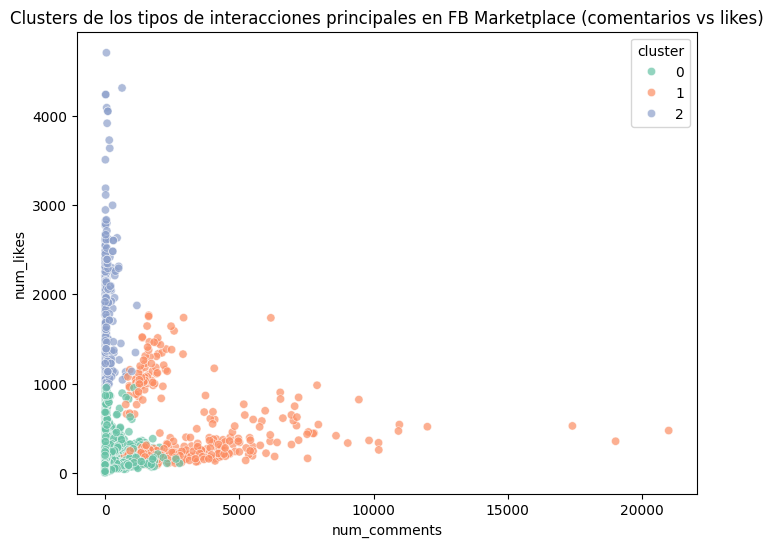

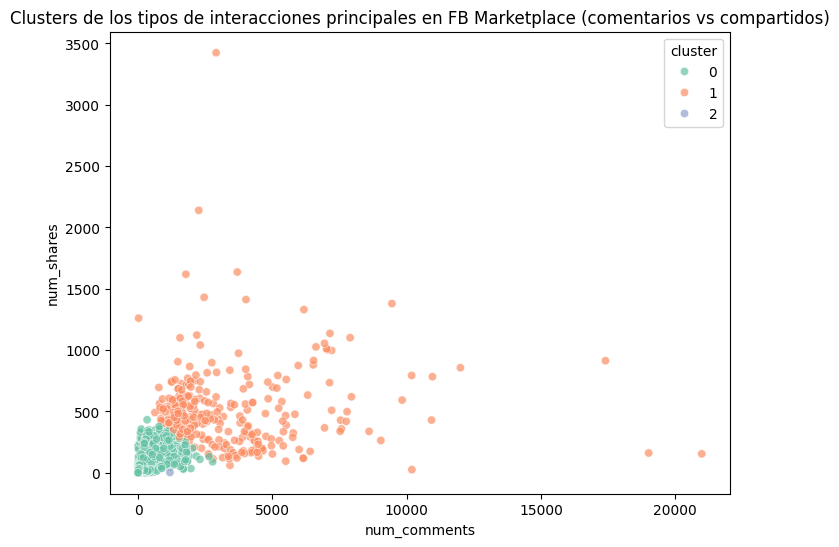

In [41]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x = 'num_comments',
    y = 'num_likes',
    hue = 'cluster',
    palette = 'Set2',
    data = df_clean,
    alpha = 0.7
)
plt.title("Clusters de los tipos de interacciones principales en FB Marketplace (comentarios vs likes)")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(
    x = 'num_comments',
    y = 'num_shares',
    hue = 'cluster',
    palette = 'Set2',
    data = df_clean,
    alpha=0.7
)
plt.title("Clusters de los tipos de interacciones principales en FB Marketplace (comentarios vs compartidos)")
plt.show()

Ya obtenidos los clustes también podemos ver los centros de los mismos así como  el número de elementos por cluster:

In [36]:
centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns = ['num_comments', 'num_shares', 'num_likes'])
print("Centros de los clusters:")
print(centers)

print("Elementos por cluster")
print(df_clean['cluster'].value_counts())

Centros de los clusters:
   num_comments  num_shares    num_likes
0     85.185604   19.009272   105.403583
1   3266.393548  502.316129   527.416129
2     71.862069   14.549072  1808.679045
Elementos por cluster
cluster
0    6363
2     377
1     310
Name: count, dtype: int64


## Respondiendo a las preguntas...

Una vez determinado los clusters y analizando los centros puedo decir que son representativos de los datos ya que comparando comentarios vs likes y comentarios vs compartidos el cluster 0 es el grupo de publicaciones con similar engament por likes y comentarios pero en general el de menor engament, el cluster 1 es el grupo de publicaciones que tiene como principal engagement los comentarios y de manera moderada y similar un engament por compartidos y likes y el cluster 2 son aquellas publicaciones cuyo principal y mayoritario engament son los likes pero aún así poseen algo de engament por comentarios y compartidos.

En pocas palabras aquellas publicaciones con un menor pero relativamente mayor cantidad de likes frente a compartidos o comentarios tienen el menor engament en general; las publicaciones con mayor engament por comentarios tienen un engament moderado y una publicación con mayor cantidad de likes suele tener la menor cantidad de comentarios y compartidos.

Regresando al análisis, el valor de k lo obtuve observando el punto en el que ya no hubiera una diferencia considerable de inercias

Y no considero que sea representativo un valor de k más alto ya que dificultaria el ver una relación entre las 3 formas principales de engament

Volviendo al análisis, los comentarios y likes tienen la mayor distancia del centro con respecto a los compartidos, y estos últimos llegan a tener la mayor distancia en el cluster 1 y 2 respectivamente

Y dado a que los datos tienen muchos outliers los grupos se ven muy dispersos

### Referencias:

1. GeeksforGeeks. (2025a, junio 24). Pandas.to_datetime()Python. GeeksforGeeks. https://www.geeksforgeeks.org/python/python-pandas-to_datetime/

2. W3Schools.com. (s. f.-b). https://www.w3schools.com/python/python_ml_k-means.asp

3. Introduction to k-Means Clustering with scikit-learn in Python. (2023, 10 marzo). Recuperado 30 de octubre de 2025, de https://www.datacamp.com/tutorial/k-means-clustering-python